# Neural Network Basics with Affon
This notebook combines the core feed-forward and recurrent examples into one walkthrough. 
It covers linear regression, logistic regression, custom object modules, and simple RNNs using the current `affon:nn` surface.


In [37]:
import {
  tensor,
  parameter,
  module,
  randn,
  linspace,
  matmul,
  add,
  sigmoid,
  clear_grad,
  grad,
  sgd,
} from 'affon:compute'
import type { Tensor } from 'affon:compute'
import nn from 'affon:nn'
import { figure, title, xlabel, ylabel, plot, scatter, savefig, show } from 'std:plot'


## Helpers

In [38]:
function asColumn(values: number[]): number[][] {
  return values.map(value => [value])
}

## Linear Regression (nn.Sequential)
Fits **y = 3x + 2** with noise using a single `nn.Linear` layer.


## Generate Data

**y = 3x + 2 + noise**

In [39]:
const xData = asColumn(linspace(0, 10, 100).to_array() as number[])
const noise = randn([xData.length, 1]).to_array() as number[][]
const yData = xData.map((row, i) => [3 * row[0] + 2 + noise[i][0] * 0.8])

const X = tensor(xData)
const y = tensor(yData)


## Model & Training

epoch 0: loss = 540.7182006835938
epoch 10: loss = 131.51756286621094
epoch 20: loss = 32.53923034667969
epoch 30: loss = 8.596223831176758
epoch 40: loss = 2.802443027496338
epoch 50: loss = 1.3985459804534912
epoch 60: loss = 1.056480050086975
epoch 70: loss = 0.971269965171814
epoch 80: loss = 0.948212206363678
epoch 90: loss = 0.9402115345001221


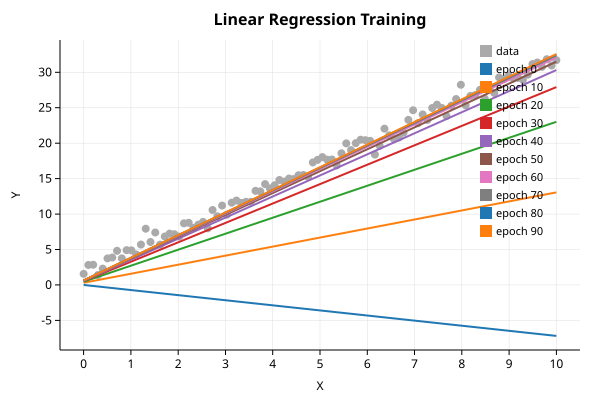

In [40]:
figure({ width: 600, height: 400 })
title('Linear Regression Training')
xlabel('X')
ylabel('Y')
scatter(X, y, { color: '#aaaaaa', label: 'data' })

const model = nn.Sequential(
  nn.Linear(1, 1)
)

const params = model.parameters
const step = sgd({ lr: 0.001 })
const criterion = nn.MSELoss()

const epochs = 100

for (let epoch = 0; epoch < epochs; epoch++) {
  clear_grad(params)
  const pred = model(X)
  const loss = criterion(pred, y)
  grad(loss, params)
  step(params)

  if (epoch % 10 === 0) {
    plot(X, pred, { label: `epoch ${epoch}` })
    console.log(`epoch ${epoch}: loss =`, loss.item())
  }
}

show()


## Linear Regression (Custom Module)
Implements `LinearRegression` manually with W and b parameters, equivalent to a PyTorch-style module.


## Custom LinearRegression Module

Forward: `X @ W + b`

In [41]:
const LinearRegression = (in_features: number, out_features: number) => {
  const W = parameter([in_features, out_features]).randn()
  const b = parameter([1, out_features]).randn()

  return module({ W, b }, (state, X: Tensor) => {
    return add(matmul(X, state.W), state.b)
  })
}


## Generate Data

**y = 3x + 2 + noise**

In [42]:
const xData = asColumn(linspace(0, 10, 100).to_array() as number[])
const noise = randn([xData.length, 1]).to_array() as number[][]
const yData = xData.map((row, i) => [3 * row[0] + 2 + noise[i][0] * 2])

const X = tensor(xData)
const y = tensor(yData)


## Model & Training

Initial parameters:
  W: [1×1 Tensor, dtype=f32]
             0
  ┌             ┐
0 │  -0.329381  │
  └             ┘

  b: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.170553  │
  └            ┘

epoch 0: loss = 441.6392517089844
epoch 10: loss = 110.06289672851562
epoch 20: loss = 29.857351303100586
epoch 30: loss = 10.4523344039917
epoch 40: loss = 5.75355339050293
epoch 50: loss = 4.611895561218262
epoch 60: loss = 4.330669403076172
epoch 70: loss = 4.257611274719238
epoch 80: loss = 4.234957695007324
epoch 90: loss = 4.224539279937744
Final parameters:
  W: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  3.189003  │
  └            ┘

  b: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.782756  │
  └            ┘



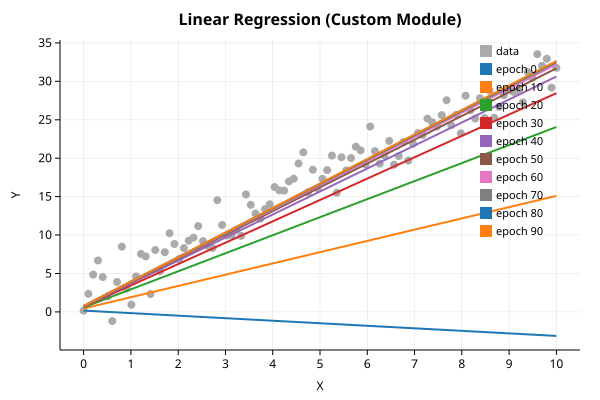

In [43]:
figure({ width: 600, height: 400 })
title('Linear Regression (Custom Module)')
xlabel('X')
ylabel('Y')
scatter(X, y, { color: '#aaaaaa', label: 'data' })

const model = LinearRegression(1, 1)

console.log('Initial parameters:')
console.log('  W:', model.W)
console.log('  b:', model.b)

const params = model.parameters
const step = sgd({ lr: 0.001 })
const criterion = nn.MSELoss()

const epochs = 100
const sample = 10

for (let epoch = 0; epoch < epochs; epoch++) {
  clear_grad(params)
  const pred = model(X)
  const loss = criterion(pred, y)
  grad(loss, params)
  step(params)

  if (epoch % sample === 0) {
    plot(X, pred, { label: `epoch ${epoch}` })
    console.log(`epoch ${epoch}: loss =`, loss.item())
  }
}

console.log('Final parameters:')
console.log('  W:', model.W)
console.log('  b:', model.b)

show()


## Logistic Regression (nn.Sequential)
Binary classification: predicts 0/1 based on a single feature. Uses sigmoid activation.


## Data

In [44]:
const X = tensor([[1], [5], [10], [10], [25], [50], [70], [75], [100]])
const Y = tensor([[0], [0], [0], [0], [0], [1], [1], [1], [1]])


## Model: Linear + Sigmoid

In [45]:
const model = nn.Sequential(
  nn.Linear(1, 1)
)

const params = model.parameters
const step = sgd({ lr: 0.004 })
const criterion = nn.BCEWithLogitsLoss()


## Training

In [46]:
const epochs = 2000
const sample = 200

const losses: number[] = []
let lastLogits = model(X)

for (let epoch = 0; epoch < epochs; epoch++) {
  clear_grad(params)
  const logits = model(X)
  const loss = criterion(logits, Y)
  grad(loss, params)
  step(params)

  losses.push(loss.item())
  lastLogits = logits

  if (epoch % sample === 0) {
    console.log('epoch', epoch, 'loss =', loss.item())
  }
}


epoch 0 loss = 33.64661407470703
epoch 200 loss = 0.4849373996257782
epoch 400 loss = 0.4400406777858734
epoch 600 loss = 0.40168190002441406
epoch 800 loss = 0.36879444122314453
epoch 1000 loss = 0.3404677212238312
epoch 1200 loss = 0.3159404993057251
epoch 1400 loss = 0.2945832312107086
epoch 1600 loss = 0.27587902545928955
epoch 1800 loss = 0.2594047486782074


## Plot: Predictions vs Targets

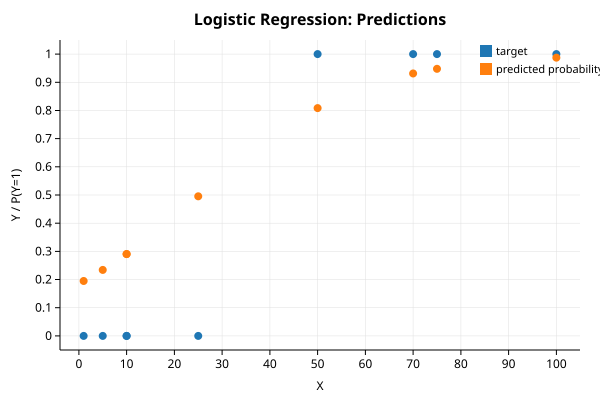

In [47]:
figure({ width: 600, height: 400 })
title('Logistic Regression: Predictions')
xlabel('X')
ylabel('Y / P(Y=1)')
scatter(X, Y, { color: '#1f77b4', label: 'target' })
scatter(X, sigmoid(lastLogits), { color: '#ff7f0e', label: 'predicted probability' })
show()


## Plot: Loss Curve

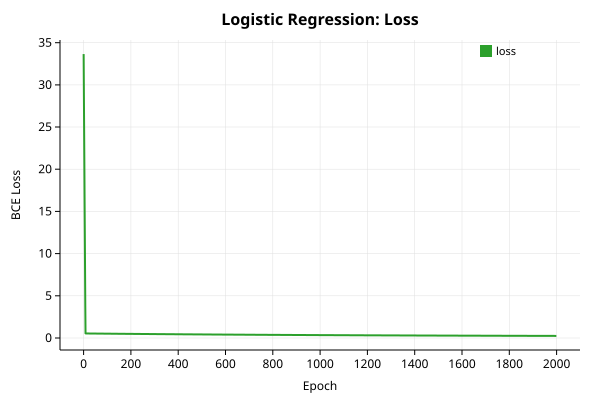

In [48]:
figure({ width: 600, height: 400 })
title('Logistic Regression: Loss')
xlabel('Epoch')
ylabel('BCE Loss')
plot(losses, { label: 'loss', color: '#2ca02c' })
show()

## Logistic Regression (Custom Module)
Uses `compute.module(...)` as the single module primitive, while `nn` supplies layers and parameter registration.


## Field Access On Object Modules

Forward: `sigmoid(X @ W + b)`

Object modules are the default path. This variant keeps `W` and `b` as owned fields on the returned module, so `model.W` and `model.b` stay accessible.


In [49]:
const LogisticRegression = (in_features: number, out_features: number) => {
  const W = parameter([in_features, out_features]).randn()
  const b = parameter([1, out_features]).randn()

  return module({ W, b }, (state, X: Tensor): Tensor => {
    return add(matmul(X, state.W), state.b)
  })
}


## Data

In [50]:
const X = tensor([[1], [5], [10], [10], [25], [50], [70], [75], [100]])
const Y = tensor([[0], [0], [0], [0], [0], [1], [1], [1], [1]])


## Model & Optimizer

In [51]:
const model = LogisticRegression(1, 1)

console.log('Initial parameters:')
console.log('  W:', model.W)
console.log('  b:', model.b)

const params = model.parameters
const step = sgd({ lr: 0.004 })
const criterion = nn.BCEWithLogitsLoss()


Initial parameters:
  W: [1×1 Tensor, dtype=f32]
             0
  ┌             ┐
0 │  -0.170863  │
  └             ┘

  b: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.188118  │
  └            ┘



## Training

In [52]:
const epochs = 2000
const sample = 200

const losses: number[] = []
let lastLogits = model(X)

for (let epoch = 0; epoch < epochs; epoch++) {
  clear_grad(params)
  const logits = model(X)
  const loss = criterion(logits, Y)
  grad(loss, params)
  step(params)

  losses.push(loss.item())
  lastLogits = logits

  if (epoch % sample === 0) {
    console.log('epoch', epoch, 'loss =', loss.item())
  }
}

console.log('Final parameters:')
console.log('  W:', model.W)
console.log('  b:', model.b)


epoch 0 loss = 5.686748504638672
epoch 200 loss = 0.5249362587928772
epoch 400 loss = 0.4741535186767578
epoch 600 loss = 0.4308362305164337
epoch 800 loss = 0.39380234479904175
epoch 1000 loss = 0.36202019453048706
epoch 1200 loss = 0.3346141576766968
epoch 1400 loss = 0.31085440516471863
epoch 1600 loss = 0.2901386022567749
epoch 1800 loss = 0.2719726264476776
Final parameters:
  W: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.056523  │
  └            ┘

  b: [1×1 Tensor, dtype=f32]
             0
  ┌             ┐
0 │  -1.394211  │
  └             ┘



## Plot: Predictions vs Targets

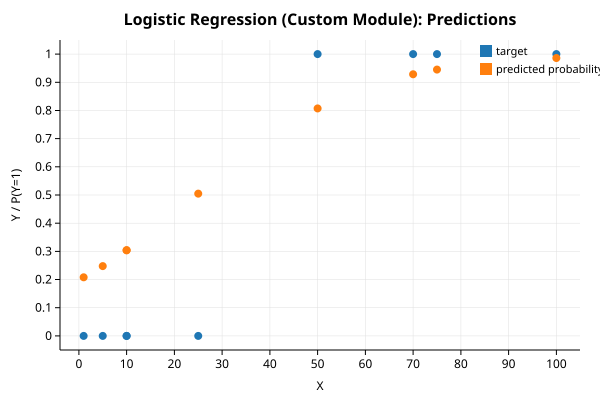

In [53]:
figure({ width: 600, height: 400 })
title('Logistic Regression (Custom Module): Predictions')
xlabel('X')
ylabel('Y / P(Y=1)')
scatter(X, Y, { color: '#1f77b4', label: 'target' })
scatter(X, sigmoid(lastLogits), { color: '#ff7f0e', label: 'predicted probability' })
show()


## Plot: Loss Curve

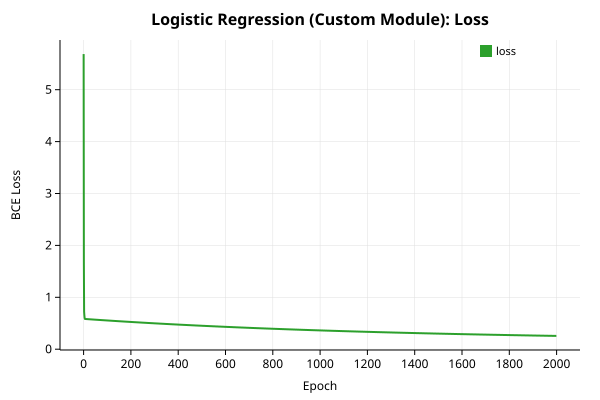

In [54]:
figure({ width: 600, height: 400 })
title('Logistic Regression (Custom Module): Loss')
xlabel('Epoch')
ylabel('BCE Loss')
plot(losses, { label: 'loss', color: '#2ca02c' })
show()

## Recurrent Neural Networks
The remaining sections move from feed-forward models to recurrent ones. 
They show both a hand-built recurrent layer and the built-in recurrent module shapes.


In [55]:
import { tensor, parameter, randn, zeros, add, matmul, tanh, stack, squeeze, clear_grad, grad, sgd } from 'affon:compute'
import nn from 'affon:nn'
import { read } from 'affon:dataset'
import { writeFileSync } from 'std:fs'
import type { Tensor } from 'affon:compute'




## Native Shape Ops
Phase 5A tensor ops let us stack hidden states directly without JS array helper functions.


In [56]:
// `stack(rows, 0)` gives [seq, 1, hidden] for row tensors shaped [1, hidden].
// `squeeze(..., 1)` removes the singleton row axis so the hidden sequence is [seq, hidden].


This notebook uses the factory + `compute.module({...})` style. `nn.module_list(...)` lets the stacked example keep array-like submodules without a manual parameter traversal.


In [59]:
const RNNLayer = (embDim: number) => {
  const W = parameter([embDim, embDim]).randn()
  const U = parameter([embDim, embDim]).randn()
  const b = parameter([1, embDim]).zeros()

  return module({ W, U, b }, (state, X: Tensor, h0?: Tensor): Tensor => {
    const seqLen = X.shape[0] as number
    let h = h0 ?? zeros([1, embDim])
    const hList: Tensor[] = []

    for (let i = 0; i < seqLen; i++) {
      const x = X.slice([`${i}:${i + 1}`, ':'])
      h = tanh(add(add(matmul(x, state.W), matmul(h, state.U)), state.b))
      hList.push(h)
    }

    return squeeze(stack(hList, 0), 1)
  })
}

const X = tensor([
  [0.1, 0.2, 0.6],
  [0.2, 0.1, 0.4],
  [0.1, 0.3, 0.3],
  [0.0, 0.7, 0.1],
  [0.5, 0.2, 0.7]
])

const layer = RNNLayer(3)
const H = layer(X)
console.log('H:', H)


H: [5×3 Tensor, dtype=f32]
             0          1          2
  ┌                                   ┐
0 │   0.408614   0.566839   0.777234  │
1 │  -0.735901    0.96493   0.814521  │
2 │   0.047185   0.842239  -0.371322  │
3 │  -0.898998  -0.903999   0.945721  │
4 │    0.99863   0.982193  -0.452462  │
  └                                   ┘



## Stacked RNN
Multiple layers, each consuming the previous layer’s hidden sequence.


In [61]:
const RNN = (embDim: number, numLayers: number) => {
  const layers = nn.module_list(numLayers, () => RNNLayer(embDim))
  let hidden_states: Tensor | null = null

  return module({
    layers,
    hidden_states() {
      return hidden_states
    },
  }, (state, X: Tensor): Tensor => {
    let H = X
    // hout includes all layers outputs
    const hout: Tensor[] = []

    for (let i = 0; i < numLayers; i++) {
      H = state.layers[i](H)
      hout.push(H)
    }

    hidden_states = stack(hout, 0)
    return H
  })
}

const model = RNN(3, 2)
const Hout = model(X)


console.log('Hout:', Hout)
console.log('hidden_states:', model.hidden_states())
console.log('parameters', model.parameters.named())


Hout: [5×3 Tensor, dtype=f32]
             0          1          2
  ┌                                   ┐
0 │   0.133799   0.036833  -0.053976  │
1 │   0.674773   0.534252   -0.94099  │
2 │   0.991987  -0.951416   0.814133  │
3 │  -0.717121  -0.358619  -0.337816  │
4 │   0.454743   0.756955  -0.932604  │
  └                                   ┘

hidden_states: [2×5×3 Tensor, dtype=f32]
[[[-0.233743, 0.10328, -0.137824], [-0.163073, 0.585753, 0.303], [-0.90546, -0.498492, 0.301992], [-0.239725, 0.028272, 0.034437], [-0.110023, 0.548208, 0.246122]], [[0.133799, 0.036833, -0.053976], [0.674773, 0.534252, -0.94099], [0.991987, -0.951416, 0.814133], [-0.717121, -0.358619, -0.337816], [0.454743, 0.756955, -0.932604]]]

parameters [ [ layers.0.W, [3×3 Tensor, dtype=f32]
             0          1          2
  ┌                                   ┐
0 │   1.290465   1.064035  -0.080345  │
1 │   0.449475    0.00047   -1.65842  │
2 │  -0.761811  -0.004747    0.33502  │
  └                          

## DataLoader Batching (affon:data)
Use a small CSV dataset and `DataLoader` to iterate sequences in batches.


In [62]:
const csv = [
  'x0,x1,x2,x3,x4,x5',
  '0.1,0.2,0.6,0.2,0.1,0.4',
  '0.1,0.3,0.3,0.0,0.7,0.1',
  '0.5,0.2,0.7,0.0,0.0,0.0',
  '0.3,0.4,0.6,0.1,0.2,0.4'
].join('\n')

const csvPath = '/tmp/rnn_sequences.csv'
writeFileSync(csvPath, csv)

const dataset = read(csvPath)
const loader = dataset.loader({ batchSize: 2 })

const seqLen = 2
const embDim = 3


const toEmbeddingSeq = (row: number[], seqLen: number, embDim: number): number[][] => {
  const seq: number[][] = []
  for (let t = 0; t < seqLen; t++) {
    seq.push(row.slice(t * embDim, (t + 1) * embDim))
  }
  return seq
}

for (const [batch] of loader) {
  const batchArr = batch.to_array() as number[][]
  const outputs = batchArr.map(row => {
    return model(tensor(toEmbeddingSeq(row, seqLen, embDim)))
  })
  console.log('batch outputs:', outputs)
}


batch outputs: [ [2×3 Tensor, dtype=f32]
            0         1          2
  ┌                                 ┐
0 │  0.133799  0.036833  -0.053976  │
1 │  0.674773  0.534252   -0.94099  │
  └                                 ┘
, [2×3 Tensor, dtype=f32]
             0         1          2
  ┌                                  ┐
0 │  -0.640449  0.298797   0.456248  │
1 │  -0.979942  0.959118  -0.283554  │
  └                                  ┘
 ]
batch outputs: [ [2×3 Tensor, dtype=f32]
             0         1          2
  ┌                                  ┐
0 │  -0.537684  0.718425   -0.60117  │
1 │   0.903261  0.005155  -0.059087  │
  └                                  ┘
, [2×3 Tensor, dtype=f32]
             0         1          2
  ┌                                  ┐
0 │   -0.76702  0.592775   0.215339  │
1 │  -0.332226   0.92485  -0.892434  │
  └                                  ┘
 ]


## Toy Token Embeddings (Affon-Only)
Affon doesn’t ship a tokenizer, so we simulate embeddings with a tiny vocab and random matrix.


In [63]:
const vocab = ['[CLS]', 'hello', 'world', '[SEP]']
const vocabIndex = new Map(vocab.map((t, i) => [t, i]))
const embDim = 4

const embeddingTable = randn([vocab.length, embDim])

function oneHot(index: number, size: number): number[] {
  return Array.from({ length: size }, (_, i) => (i === index ? 1 : 0))
}

const tokens = ['hello', 'world']
const oneHotMatrix = tokens.map(t => oneHot(vocabIndex.get(t)!, vocab.length))

// (numTokens x vocab) @ (vocab x embDim) = (numTokens x embDim)
const tokenEmbeddings = matmul(tensor(oneHotMatrix), embeddingTable)

console.log('tokenEmbeddings:', tokenEmbeddings)


tokenEmbeddings: [2×4 Tensor, dtype=f32]
            0          1         2          3
  ┌                                            ┐
0 │  0.060902  -0.656819  1.557365   0.436375  │
1 │  0.805953   0.857322  0.982277  -1.035677  │
  └                                            ┘

